### Кастомный ViT (baseline)

Самостоятельная реализация ViT-Tiny, Adam + StepLR, 10 эпох, без аугментаций. Сравнение с Swin-T baseline.

In [1]:
from common import *

In [ ]:
with open("outputs/splits_info.json", "r") as f: # загрузка информации о разбиении набора данных
    cfg = json.load(f)

CLASS_NAMES = cfg["class_names"] # список классов
BATCH_SIZE = cfg["batch_size"] # размер батча
IMG_SIZE = cfg["img_size"] # размер изображения
train_indices = cfg["train_indices"] # индексы тренировочного набора
val_indices = cfg["val_indices"] # индексы валидационного набора
SEED = cfg["seed"] # seed для повторяемости

train_dataset = BloodCellsDataset(TRAIN_DIR, transform=train_transform) # создание тренировочного набора
val_dataset = BloodCellsDataset(TRAIN_DIR, transform=val_test_transform) # создание валидационного набора
test_dataset = BloodCellsDataset(TEST_DIR, transform=val_test_transform) # создание тестового набора

train_dataset.samples = [train_dataset.samples[i] for i in train_indices] # изменение списка образцов тренировочного набора
val_dataset.samples = [val_dataset.samples[i] for i in val_indices] # изменение списка образцов валидационного набора

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для тренировочного набора
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для валидационного набора
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для тестового набора

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 7965, Val: 1992, Test: 2487


In [ ]:
def train_custom(model, model_name, train_loader, val_loader, test_loader, epochs, optimizer, scheduler, criterion, device=DEVICE, use_amp=True):
    """ Функция обучение модели """
    set_seed(SEED)
    model = model.to(device) # перенос модели на устройство
    scaler = torch.amp.GradScaler("cuda") if (use_amp and device.type == "cuda") else None # создание масштабирующего фактора
    history = {"train_loss": [], "val_loss": [], "val_acc": [], "train_acc": []} # словарь для хранения истории обучения

    for epoch in range(epochs): # цикл по эпохам
        model.train() # установка модели в режим обучения
        running_loss = 0.0 # инициализация переменной для хранения потерь
        all_preds, all_labels = [], [] # инициализация списков для хранения предсказаний и меток
        for images, labels in train_loader: # цикл по тренировочному набору
            images, labels = images.to(device), labels.to(device) # перенос изображений и меток на устройство
            optimizer.zero_grad() # обнуление градиентов
            if scaler: # проверка на масштабирующий фактор
                with torch.amp.autocast("cuda"): # включение автоматического масштабирования
                    outputs = model(images) # прямой проход модели
                    loss = criterion(outputs, labels) # вычисление потерь
                scaler.scale(loss).backward() # обратный проход с масштабированием
                scaler.step(optimizer) # обновление весов
                scaler.update() # обновление масштабирующего фактора
            else:
                outputs = model(images) # прямой проход модели
                loss = criterion(outputs, labels) # вычисление потерь
                loss.backward() # обратный проход
                optimizer.step() # обновление весов
            running_loss += loss.item() * images.size(0) # обновление переменной для хранения потерь
            _, preds = torch.max(outputs, 1) # получение предсказаний
            all_preds.extend(preds.cpu().numpy()) # добавление предсказаний в список
            all_labels.extend(labels.cpu().numpy()) # добавление меток в список
        train_loss = running_loss / len(train_loader.dataset) # вычисление среднего потерь
        train_acc = accuracy_score(all_labels, all_preds) # вычисление точности
        val_loss, val_acc, val_bal_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device) # оценка модели на валидационном наборе
        if scheduler is not None: # проверка на планировщик
            scheduler.step() # обновление планировщика
        history["train_loss"].append(train_loss) # добавление потерь в историю
        history["val_loss"].append(val_loss) # добавление потерь в историю
        history["train_acc"].append(train_acc) # добавление точности в историю
        history["val_acc"].append(val_acc) # добавление точности в историю

        # вывод информации о прогрессе обучения
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val Bal Acc: {val_bal_acc:.4f}, Val F1: {val_f1:.4f}")

    test_loss, test_acc, test_bal_acc, test_f1, test_preds, test_labels = evaluate(model, test_loader, criterion, device) # проверка на тестовом наборе
    # вывод метрик на тестовом наборе
    print(f"\n{model_name} - TEST")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"Balanced Accuracy: {test_bal_acc:.4f}")
    print(f"Macro-F1: {test_f1:.4f}")

    # построение матрицы ошибок
    cm = confusion_matrix(test_labels, test_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"{model_name} - Confusion Matrix")
    plt.tight_layout(); plt.show()

    # построение графика потерь и точности
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss"); axes[0].legend()
    axes[1].plot(history["train_acc"], label="Train Acc")
    axes[1].plot(history["val_acc"], label="Val Acc")
    axes[1].set_title("Accuracy"); axes[1].legend()
    plt.tight_layout(); plt.show()

    # вывод отчета о классификации
    print(f"\n{model_name} - Classification report:")
    print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

    # возвращение модели и результатов
    return model, {
        "model": model_name, "test_acc": test_acc, "test_bal_acc": test_bal_acc,
        "test_f1_macro": test_f1, "history": history, "confusion_matrix": cm.tolist(),
    }

In [ ]:
class MultiHeadAttention(nn.Module): # класс для мульти-головного внимания
    def __init__(self, dim, num_heads, dropout=0.1): # инициализация
        super().__init__() # вызов инициализации родительского класса
        assert dim % num_heads == 0 # проверка на делимость
        self.num_heads = num_heads # количество голов
        self.head_dim = dim // num_heads # размер головы
        self.scale = self.head_dim ** -0.5 # масштаб
        self.qkv = nn.Linear(dim, dim * 3) # линейный слой для qkv
        self.proj = nn.Linear(dim, dim) # линейный слой для проекции
        self.dropout = nn.Dropout(dropout) # слой для dropout

    def forward(self, x): # прямой проход
        B, N, D = x.shape # получение размеров входного тензора
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4) # линейный слой для qkv
        q, k, v = qkv[0], qkv[1], qkv[2] # получение q, k, v
        attn = (q @ k.transpose(-2, -1)) * self.scale # вычисление матрицы внимания
        attn = attn.softmax(dim=-1) # softmax по последнему измерению
        attn = self.dropout(attn) # dropout
        out = (attn @ v).transpose(1, 2).reshape(B, N, D) # вычисление выхода
        return self.dropout(self.proj(out)) # линейный слой для проекции


class MLP(nn.Module): # класс для многослойного перцептрона
    def __init__(self, dim, mlp_dim, dropout=0.1): # инициализация
        super().__init__() # вызов инициализации родительского класса
        self.net = nn.Sequential( # последовательность слоев
            nn.Linear(dim, mlp_dim), # линейный слой
            nn.GELU(), # GELU активация
            nn.Dropout(dropout), # слой для dropout
            nn.Linear(mlp_dim, dim), # линейный слой
            nn.Dropout(dropout), # слой для dropout
        )

    def forward(self, x): # прямой проход
        return self.net(x) # вычисление выхода


class TransformerBlock(nn.Module): # класс для блока трансформатора
    def __init__(self, dim, num_heads, mlp_dim, dropout=0.1): # инициализация
        super().__init__() # вызов инициализации родительского класса
        self.norm1 = nn.LayerNorm(dim) # нормализация
        self.attn = MultiHeadAttention(dim, num_heads, dropout) # мульти-головное внимание
        self.norm2 = nn.LayerNorm(dim) # нормализация
        self.mlp = MLP(dim, mlp_dim, dropout) # многослойный перцептрон

    def forward(self, x): # прямой проход
        x = x + self.attn(self.norm1(x)) # добавление мульти-головного внимания
        x = x + self.mlp(self.norm2(x)) # добавление многослойного перцептрона
        return x # возвращение результата


class CustomViT(nn.Module): # класс для кастомного ViT
    """Vision Transformer с нуля (ViT-Tiny): только nn.*, без готовой архитектуры."""
    def __init__(self, img_size=224, patch_size=16, in_ch=3, num_classes=4,
                 d_model=192, depth=4, num_heads=3, mlp_ratio=4.0, dropout=0.1): # инициализация
        super().__init__() # вызов инициализации родительского класса
        num_patches = (img_size // patch_size) ** 2 # вычисление количества патчей
        self.patch_embed = nn.Conv2d(in_ch, d_model, kernel_size=patch_size, stride=patch_size) # линейный слой для патч-эмбеддинга
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model)) # параметр для классового токена
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, d_model)) # параметр для позиционного эмбеддинга
        self.dropout = nn.Dropout(dropout) # слой для dropout
        mlp_dim = int(d_model * mlp_ratio) # вычисление размерности многослойного перцептрона
        self.blocks = nn.Sequential(*[ # последовательность блоков трансформатора
            TransformerBlock(d_model, num_heads, mlp_dim, dropout) for _ in range(depth) # блоки трансформатора
        ])
        self.norm = nn.LayerNorm(d_model) # линейный слой для проекции
        self.head = nn.Linear(d_model, num_classes) # линейный слой для классификации
        nn.init.trunc_normal_(self.pos_embed, std=0.02) # инициализация позиционного эмбеддинга
        nn.init.trunc_normal_(self.cls_token, std=0.02) # инициализация классового токена

    def forward(self, x): # прямой проход
        B = x.shape[0] # получение количества батчей
        x = self.patch_embed(x) # патч-эмбеддинг
        x = x.flatten(2).transpose(1, 2) # сглаживание и транспонирование
        cls = self.cls_token.expand(B, -1, -1) # расширение классового токена
        x = torch.cat([cls, x], dim=1) # конкатенация классового токена и патч-эмбеддинга
        x = x + self.pos_embed # добавление позиционного эмбеддинга
        x = self.dropout(x) # dropout
        x = self.blocks(x) # блоки трансформатора
        x = self.norm(x) # нормализация
        return self.head(x[:, 0]) # линейный слой для классификации

Epoch 1/10 - Train Loss: 1.4387, Train Acc: 0.2384 - Val Loss: 1.3913, Val Acc: 0.2510, Val Bal Acc: 0.2500, Val F1: 0.1003
Epoch 2/10 - Train Loss: 1.3863, Train Acc: 0.2718 - Val Loss: 1.3614, Val Acc: 0.3213, Val Bal Acc: 0.3210, Val F1: 0.2198
Epoch 3/10 - Train Loss: 1.2497, Train Acc: 0.3828 - Val Loss: 1.1663, Val Acc: 0.4232, Val Bal Acc: 0.4235, Val F1: 0.4177
Epoch 4/10 - Train Loss: 1.0829, Train Acc: 0.5019 - Val Loss: 1.0144, Val Acc: 0.5698, Val Bal Acc: 0.5705, Val F1: 0.5429
Epoch 5/10 - Train Loss: 0.8575, Train Acc: 0.6424 - Val Loss: 0.8277, Val Acc: 0.6692, Val Bal Acc: 0.6691, Val F1: 0.6593
Epoch 6/10 - Train Loss: 0.5450, Train Acc: 0.7930 - Val Loss: 0.4762, Val Acc: 0.8158, Val Bal Acc: 0.8160, Val F1: 0.8149
Epoch 7/10 - Train Loss: 0.4716, Train Acc: 0.8183 - Val Loss: 0.4056, Val Acc: 0.8429, Val Bal Acc: 0.8431, Val F1: 0.8430
Epoch 8/10 - Train Loss: 0.4415, Train Acc: 0.8269 - Val Loss: 0.3816, Val Acc: 0.8454, Val Bal Acc: 0.8456, Val F1: 0.8454
Epoch 9/

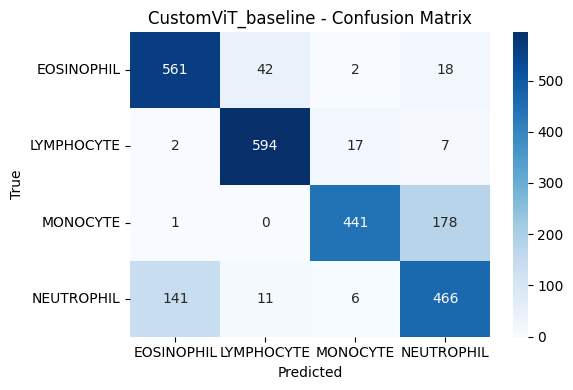

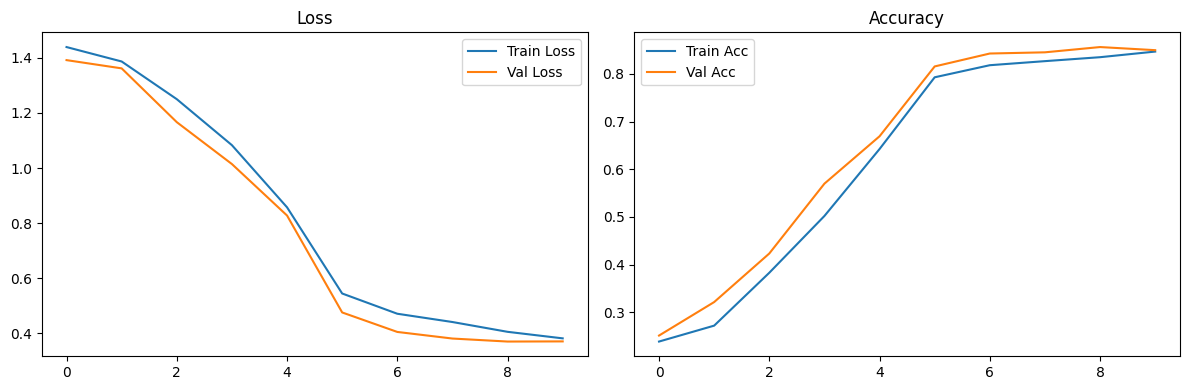


CustomViT_baseline - Classification report:
              precision    recall  f1-score   support

  EOSINOPHIL       0.80      0.90      0.84       623
  LYMPHOCYTE       0.92      0.96      0.94       620
    MONOCYTE       0.95      0.71      0.81       620
  NEUTROPHIL       0.70      0.75      0.72       624

    accuracy                           0.83      2487
   macro avg       0.84      0.83      0.83      2487
weighted avg       0.84      0.83      0.83      2487

Веса сохранены: outputs/custom_vit_baseline.pth


In [ ]:
set_seed(SEED)
model = CustomViT(img_size=IMG_SIZE, num_classes=len(CLASS_NAMES)) # создание модели
optimizer = optim.Adam(model.parameters(), lr=1e-3) # оптимизатор
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1) # планировщик
criterion = nn.CrossEntropyLoss() # критерий

model, result = train_custom(
    model, "CustomViT_baseline",
    train_loader, val_loader, test_loader,
    epochs=10, optimizer=optimizer, scheduler=scheduler, criterion=criterion, device=DEVICE,
)

os.makedirs("outputs", exist_ok=True)
torch.save(model.state_dict(), "outputs/custom_vit_baseline.pth") # сохранение весов
print("Веса сохранены: outputs/custom_vit_baseline.pth")

Кастомный Vision Transformer с нуля достиг Accuracy 0.8291, Balanced Accuracy 0.8292, Macro-F1 0.8289 — заметно хуже, чем Swin-T baseline (0.8802) и кастомная CNN (0.8762). 

Обучение началось крайне медленно: на эпохе 1 train Accuracy составлял лишь ~24% (близко к случайному угаданию при 4 классах). Только к эпохам 8–10 модель начала уверенно различать классы. Это классическое поведение трансформера на малых данных: механизм взаимосвязей требует большого числа примеров, чтобы научиться выстраивать осмысленные зависимости между 197 патчами изображения.

In [ ]:
all_results = load_results()
all_results["CustomVit"] = result # добавление результатов в словарь

df_cosine = pd.DataFrame([result]) # создание DataFrame с результатами
baseline_models = pd.DataFrame([ # создание DataFrame с результатами базовых моделей
    all_results["baseline_resnet18"], # результаты базовой модели ResNet18
    all_results["baseline_swin"], # результаты базовой модели Swin
])

df_compare = pd.concat([baseline_models, df_cosine], ignore_index=True) # создание DataFrame с результатами сравнения

print("Baseline vs CustomVIT:")
display(df_compare[["model", "test_acc", "test_bal_acc", "test_f1_macro"]]) # вывод результатов сравнения
save_results(all_results)

Baseline vs CustomVIT:


,model,test_acc,test_bal_acc,test_f1_macro
0,ResNet18,0.854443,0.854462,0.858832
1,Swin-T,0.880177,0.880147,0.883016
2,CustomViT_baseline,0.829111,0.829158,0.828872


Результаты сохранены в outputs/experiment_results.pkl


Имплементация без предобучения значительно уступает как готовому Swin-T, так и кастомной CNN. На датасете ~8k изображений трансформер просто не успевает сформировать полезные attention-паттерны за 10 эпох, что подтверждает известное ограничение ViT-архитектур при обучении с нуля на небольших данных.